CODE SANS VAPEUR

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


#### FONCTIONS UTILES

def Rayleigh_x(g, alpha, Tw, TB, x, nu, a):
    return (g * alpha * (abs(Tw - TB)) * x**3) / (nu * a)

def Ub(m_point_CL,delta,rho_liq,R):
    if delta==0:
        return(0)
    else:
        return(m_point_CL/(2*np.pi*R*delta*rho_liq))

def Grashof_x(g, beta, Tw, TB, x, nu):
    return (g * beta * (abs(Tw - TB)) * x**3) / (nu**2)

def Rayleigh_x(g, alpha, Tw, TB, x, nu, a):
    return (g * alpha * max(abs(Tw - TB), 1e-6) * x**3) / (nu * a)

def k_nat(Rax, lambda_l, x):
    if Rax < 1e9: return 0.59 * (Rax ** 0.25) * lambda_l / x
    return 0.11 * (Rax ** (1/3)) * lambda_l / x

def tau_w_turb(rho, ub, g, beta, Tw, TB, x, nu):
    Grx = Grashof_x(g, beta, Tw, TB, x, nu)
    return rho * (ub**2) * 0.684 * (Grx ** (1/11.9))

##### PARAMETRES
Nx = 50
q_ext = 2000
temps_total=1200 # secondes simulées
dt = 0.2
proportion_liquide=0.85


##### CONSTANTES
R = 0.2; hauteur = 0.6; delta_w = 0.007
g = 9.81
H_liq_init = hauteur * proportion_liquide
Nx = 50
dx = H_liq_init / Nx
num_iterations = int(temps_total/dt)


# liquide
rho_l = 502.59; lam_l = 0.097; cp_l = 2649.5 ; cv_l=1640.1 ;
nu_l = 2.07e-7; beta_l = 1.3e-3; a_l = lam_l/(rho_l*cp_l); Pr_l = nu_l/a_l

# mur
rho_w = 7930; lam_w = 15.24; c_w = 500

# surfaces utiles
A_ext = 2*np.pi*(R+delta_w)*dx
A_int = 2*np.pi*R*dx
A_cross = np.pi*((R+delta_w)**2 - R**2)
A_bulk = np.pi*R**2

# propriétés thermiques associées
m_w_i = rho_w * A_cross * dx
capa_w_i = m_w_i * c_w
M_bulk_i = rho_l * A_bulk * dx
capa_bulk_i = M_bulk_i * cv_l
K_cond_bulk = lam_l * A_bulk / dx


#### INITIALISATION

Ti = 291.47

temp_bulk = np.full(Nx, Ti)
temp_moy_cl = np.full(Nx, Ti + 0.01)
Tw = np.full(Nx, Ti)
m_point_CL = np.zeros(Nx+1)
delta = np.full(Nx, 0.001)

U_init = np.sum(M_bulk_i * cv_l * temp_bulk) + np.sum(m_w_i * c_w * Tw)
energy_input_total = 0.0

history_energy_error, history_temp_bulk, time_stamps = [], [], []


#### Listes pour les plots

history_temp_bulk = []
history_delta = []
history_m_dot     = []
time_stamps = []


# BOUCLE TEMPORELLE

for it in range(num_iterations):

    #### PAROI LIQUIDE ####
    Tw_new = np.copy(Tw)
    q_conv_save = np.zeros(Nx)
    for i in range(Nx):
        x_i = (i + 0.5) * dx
        Ra_i = Rayleigh_x(g, beta_l, Tw[i], temp_bulk[i], x_i, nu_l, a_l)
        q_conv_save[i] = k_nat(Ra_i, lam_l, x_i)* (Tw[i] - temp_bulk[i])

        P_cond = (lam_w*A_cross/dx) * ((Tw[i-1]-Tw[i] if i>0 else 0) + (Tw[i+1]-Tw[i] if i<Nx-1 else 0))
        Tw_new[i] += (dt/capa_w_i) * (q_ext * A_ext - q_conv_save[i] * A_int + P_cond)
    Tw = Tw_new

    #### COUCHE LIMITE ####
    for i in range(Nx):
        x_i = (i + 0.5) * dx
        Gri = Grashof_x(g, beta_l, Tw[i], temp_bulk[i], x_i, nu_l)
        Rai = Gri * Pr_l

        # Calcul de la taille de la couche limite via corrélation
        if Rai < 1e9:
            delta[i] = 3.93 * x_i * ((0.952 + Pr_l) / (Gri * Pr_l**2))**0.25
        else:
            delta[i] = 0.565 * x_i * ((1 + 0.494 * Pr_l**(2/3))**0.1) / (Gri**0.1 * Pr_l**(8/15))

        # Initialisation de la boucle de convergence
        eps = 1.0
        k_iter = 0
        temp_moy_cl[i] = temp_bulk[i] + max(Tw[i] - temp_bulk[i], 1e-3) * 0.5

        # Boucle itérative : Énergie / Quantité de mouvement
        while eps > 0.0001 and k_iter < 1000:
            temp_moy_cl[i] = max(temp_moy_cl[i], temp_bulk[i] + 1e-4)

            # 1 : Calcul du débit m_dot basé sur l'énergie
            phi = q_conv_save[i] * A_int
            T_cl_in = temp_moy_cl[i-1] if i > 0 else temp_bulk[0]
            denom = cp_l * (temp_moy_cl[i] - temp_bulk[i])
            m_point_CL[i+1] = (phi + m_point_CL[i] * cp_l* (T_cl_in - temp_bulk[i])) / denom if abs(denom) > 1e-6 else 0.0 #####

            # 2 : Calcul de la vitesse et du cisaillement
            u_i = Ub(0.5 * (m_point_CL[i+1] + m_point_CL[i]), delta[i], rho_l, R)
            tau_i = tau_w_turb(rho_l, u_i, g, beta_l, Tw[i], temp_bulk[i], x_i, nu_l)
            A_grad = (m_point_CL[i+1] - m_point_CL[i]) / dx

            # 3 : Nouvelle estimation de la température via bilan thermo-mécanique
            temp_new = temp_bulk[i] + tau_i / (rho_l * g * beta_l * delta[i]) + \
                       3.25 * 0.5 * (m_point_CL[i+1] + m_point_CL[i]) * (2 * A_grad) / ((2 * np.pi * R * rho_l * delta[i])**2) / (g * beta_l)

            # Check convergence
            eps = abs(temp_moy_cl[i] - temp_new)
            temp_moy_cl[i] = 0.8 * temp_moy_cl[i] + 0.2 * temp_new # Relaxation
            k_iter += 1

    #### BULK ####
    m_B = m_point_CL.copy()
    temp_bulk_new = np.copy(temp_bulk)
    for i in range(Nx):
        # Flux Advectifs
        H_top = m_B[i+1] * cp_l * (temp_bulk[i+1] if i < Nx-1 else temp_moy_cl[Nx-1])
        H_bot = m_B[i] * cp_l * temp_bulk[i]

        # Flux Latéral
        m_y = -m_B[i] + m_B[i+1]
        H_lat = m_y * cp_l * temp_bulk[i]

        # Conduction
        P_cond_b = K_cond_bulk * ((temp_bulk[i-1]-temp_bulk[i] if i>0 else 0) + (temp_bulk[i+1]-temp_bulk[i] if i<Nx-1 else 0))

        temp_bulk_new[i] += (dt/capa_bulk_i) * (H_top - H_bot - H_lat + P_cond_b)
    temp_bulk = temp_bulk_new


    #### BILAN DE CONSERVATION D'ENERGIE ####
    U_actuel = np.sum(M_bulk_i * cv_l * temp_bulk) + np.sum(m_w_i * c_w * Tw)
    energy_input_total += (q_ext * A_ext * Nx) * dt
    err_E = abs(((U_actuel - U_init) - energy_input_total))

    if it % int(100/dt) == 0:
        history_temp_bulk.append(np.copy(temp_bulk))
        history_delta.append(np.copy(delta))
        history_m_dot.append(np.copy(m_point_CL[1:]))
        time_stamps.append(int(it*dt))
        history_energy_error.append(err_E)
        print(f"t={it*dt:4.0f}s | Err_E={err_E:8.5f} J | TB_haut={temp_bulk[-1]:.2f} K | TB_bas={temp_bulk[0]:.2f} K")


t=   0s | Err_E= 0.00000 J | TB_haut=291.47 K | TB_bas=291.47 K
t= 200s | Err_E= 5.31940 J | TB_haut=298.71 K | TB_bas=291.47 K
t= 400s | Err_E= 0.37297 J | TB_haut=303.76 K | TB_bas=291.47 K
t= 600s | Err_E= 7.36161 J | TB_haut=308.30 K | TB_bas=291.49 K
t= 800s | Err_E=15.07269 J | TB_haut=312.60 K | TB_bas=291.93 K
t=1000s | Err_E=21.87511 J | TB_haut=316.75 K | TB_bas=293.37 K


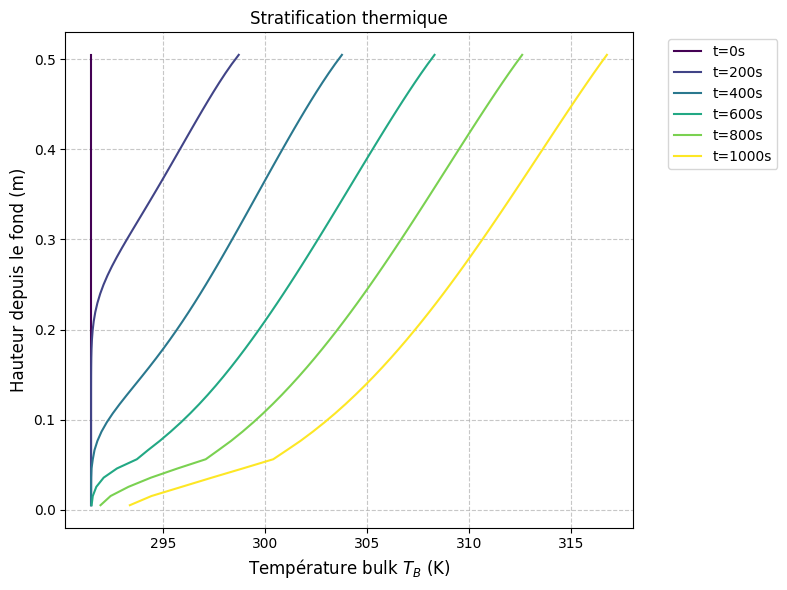

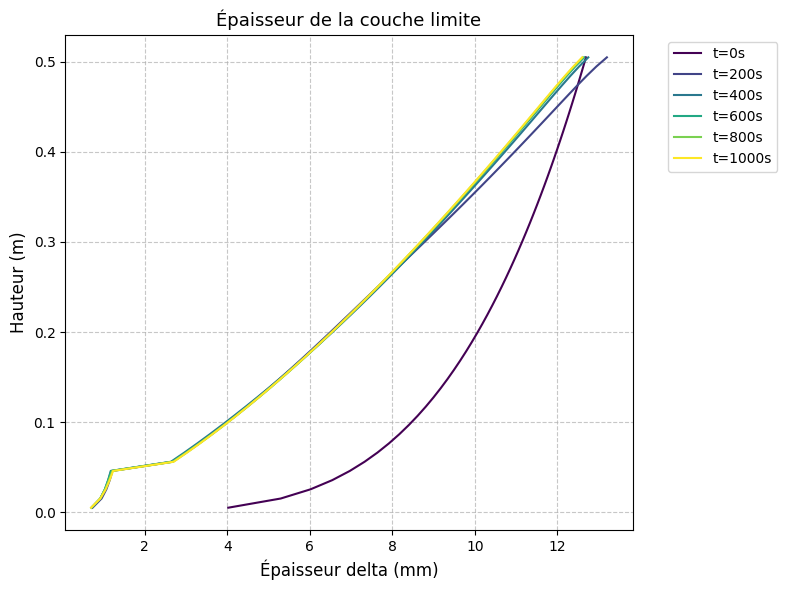

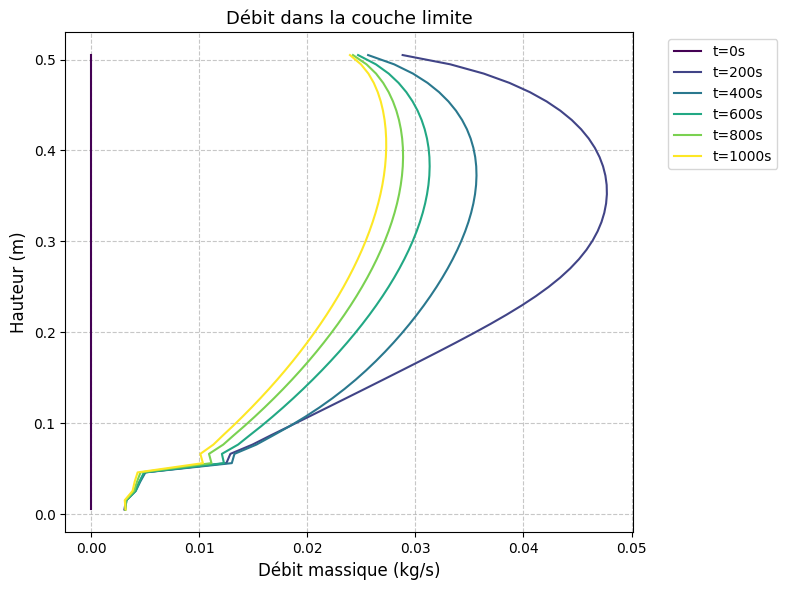

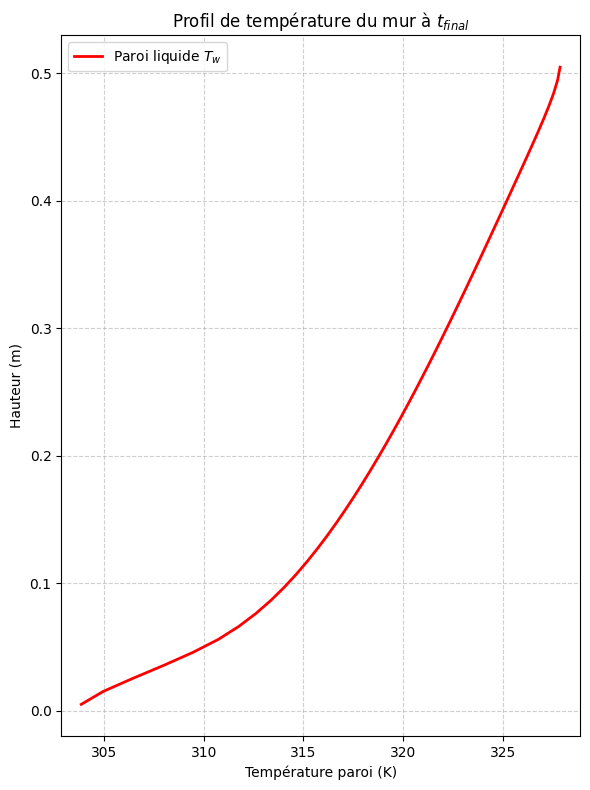

In [3]:
#### PLOT ####

y_coords = np.linspace(dx/2, H_liq_init-dx/2, Nx)
colors   = cm.viridis(np.linspace(0, 1, len(history_temp_bulk)))

# Stratification thermique
plt.figure(figsize=(8,6))
for idx, (t_profile, time) in enumerate(zip(history_temp_bulk, time_stamps)):
    plt.plot(t_profile, y_coords, color=colors[idx], label=f't={time}s')
plt.xlabel('Température bulk $T_B$ (K)', fontsize=12)
plt.ylabel('Hauteur depuis le fond (m)', fontsize=12)
plt.title('Stratification thermique', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Épaisseur couche limite
plt.figure(figsize=(8,6))
for idx, (d_profile, time) in enumerate(zip(history_delta, time_stamps)):
    plt.plot(d_profile*1000, y_coords, color=colors[idx], label=f't={time}s')
plt.xlabel('Épaisseur delta (mm)', fontsize=12)
plt.ylabel('Hauteur (m)', fontsize=12)
plt.title("Épaisseur de la couche limite", fontsize=13)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Débit massique
plt.figure(figsize=(8,6))
for idx, (d_profile, time) in enumerate(zip(history_m_dot, time_stamps)):
    plt.plot(d_profile, y_coords, color=colors[idx], label=f't={time}s')
plt.xlabel('Débit massique (kg/s)', fontsize=12)
plt.ylabel('Hauteur (m)', fontsize=12)
plt.title("Débit dans la couche limite", fontsize=13)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Température en paroi
plt.figure(figsize=(6,8))
plt.plot(Tw, y_coords, 'r-', lw=2, label='Paroi liquide $T_w$')
plt.xlabel('Température paroi (K)'); plt.ylabel('Hauteur (m)')
plt.title('Profil de température du mur à $t_{final}$')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend()
plt.xlim(min(Tw)-1, max(Tw)+1); plt.tight_layout(); plt.show()

CODE AVEC VAPEUR


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


#### FONCTIONS UTILES

def Rayleigh_x(g, alpha, Tw, TB, x, nu, a):
    return (g * alpha * (abs(Tw - TB)) * x**3) / (nu * a)

def Ub(m_point_CL,delta,rho_liq,R):
    if delta==0:
        return(0)
    else:
        return(m_point_CL/(2*np.pi*R*delta*rho_liq))

def Grashof_x(g, beta, Tw, TB, x, nu):
    return (g * beta * (abs(Tw - TB)) * x**3) / (nu**2)

def Rayleigh_x(g, alpha, Tw, TB, x, nu, a):
    return (g * alpha * max(abs(Tw - TB), 1e-6) * x**3) / (nu * a)

def k_nat(Rax, lambda_l, x):
    if Rax < 1e9: return 0.59 * (Rax ** 0.25) * lambda_l / x
    return 0.11 * (Rax ** (1/3)) * lambda_l / x

def tau_w_turb(rho, ub, g, beta, Tw, TB, x, nu):
    Grx = Grashof_x(g, beta, Tw, TB, x, nu)
    return rho * (ub**2) * 0.684 * (Grx ** (1/11.9))
def q_in_wall(Tw, TB, Rax, x, lambda_l):
    return k_nat(Rax, lambda_l, x) * (Tw - TB)

#### FONCTIONS INTERFACE VAPEUR-LIQUIDE  ####

def compute_k_v_int(Tv, Tint, D, rho_v, cp_v, nu_v, lambda_v, g, beta):
    dT = abs(Tv - Tint)
    if dT < 1e-8:
        return 0.0
    a_v = lambda_v / (rho_v * cp_v)
    Ra  = g * beta * dT * D**3 / (nu_v * a_v)
    return 0.54 * (max(Ra, 1e-10) ** 0.25) * lambda_v / D

def compute_k_int_l(Tint, Ts, D, rho_l, cp_l, nu_l, lambda_l, g, beta):
    dT = abs(Tint - Ts)
    if dT < 1e-8:
        return 0.0
    a_l = lambda_l / (rho_l * cp_l)
    Ra  = g * beta * dT * D**3 / (nu_l * a_l)
    return 0.27 * (max(Ra, 1e-10) ** 0.25) * lambda_l / D

def saturation_temperature(P, Pref=800e3, Tref=291.47, gamma=3.56e5, r=188.5):
    val = 1.0/Tref - (r/gamma) * np.log(max(P, 1e3)/Pref)
    return 1.0/val if val > 0 else Tref

def saturation_pressure(T, Pref=800e3, Tref=291.47, gamma=3.56e5, r=188.5):
    return Pref * np.exp((gamma/r) * (1.0/Tref - 1.0/T))

def rho_v_sat(P, r=188.5):
    return P / (r * saturation_temperature(P))

##### PARAMETRES
Nx = 50
q_ext = 2000
temps_total=1200 # secondes simulées
dt = 0.02
proportion_liquide=0.85
hauteur = 0.6
H_liq_init = hauteur * proportion_liquide


##### CONSTANTES
R = 0.2; delta_w = 0.007
g = 9.81
dx = H_liq_init / Nx
num_iterations = int(temps_total/dt)


# liquide
rho_l = 502.59; lam_l = 0.097; cp_l = 2649.5 ; cv_l=1640.1 ;
nu_l = 2.07e-7; beta_l = 1.3e-3; a_l = lam_l/(rho_l*cp_l); Pr_l = nu_l/a_l
gamma_lat = 3.56e5    # J/kg

# mur
rho_w = 7930; lam_w = 15.24; c_w = 500

# vapeur
nu_v  = 4.64e-7;  rho_v0 = 17.291;  lam_v = 0.018
cp_v  = 1928.5;   cv_v   = 1533.9
a_v0  = lam_v/(rho_v0*cp_v)

# surfaces utiles
A_ext = 2*np.pi*(R+delta_w)*dx
A_int = 2*np.pi*R*dx
A_cross = np.pi*((R+delta_w)**2 - R**2)
A_bulk = np.pi*R**2
D_tank  = 2*R
H_s   = dx    # hauteur du Surface CV



# propriétés thermiques associées
m_w_i = rho_w * A_cross * dx
capa_w_i = m_w_i * c_w
M_bulk_i = rho_l * A_bulk * dx
capa_bulk_i = M_bulk_i * cv_l
K_cond_bulk = lam_l * A_bulk / dx
capa_surf   = (rho_l * A_bulk * H_s) * cp_l


#### INITIALISATION


H_liq_init = hauteur * proportion_liquide
H_vap_init = hauteur * (1 - proportion_liquide)
Ti = 291.47
Pv   = 800e3
Tv   = saturation_temperature(Pv)   # = Ti = 291.47 K
Ts   = Ti
Tint = Ti
Tw_vap=Ti



H_vap = H_vap_init
V_v   = A_bulk * H_vap
rho_v = rho_v_sat(Pv)
m_v   = rho_v * V_v


temp_bulk = np.full(Nx, Ti)
temp_moy_cl = np.full(Nx, Ti + 0.01)
Tw = np.full(Nx, Ti)
m_point_CL = np.zeros(Nx+1)
delta = np.full(Nx, 0.001)

U_init = np.sum(M_bulk_i * cv_l * temp_bulk) + np.sum(m_w_i * c_w * Tw)
energy_input_total = 0.0

history_energy_error, history_temp_bulk, time_stamps = [], [], []


#### Tableaux pour tracés

history_temp_bulk = []
history_delta     = []
history_Tv        = []
history_Ts        = []
history_Pv        = []
history_m_dot     = []
time_stamps       = []


## Surface et capacité vapeur
A_int_v_total = 2 * np.pi * R * H_vap          # Surface intérieure totale gaz
A_ext_v_total = 2 * np.pi * (R + delta_w) * H_vap  # Surface extérieure totale gaz
m_w_vap_total = rho_w * A_cross * H_vap        # Masse totale de la paroi gaz
capa_wv_total = m_w_vap_total * c_w            # Capacité thermique totale paroi gaz



#### INITIALISATION DU BILAN D'ÉNERGIE ####
m_v_init = m_v
energy_input_total = 0.0

# Énergie interne initiale (Liquide + Parois Liquide + Paroi Vapeur + Surface + Gaz)
U_init = (np.sum(M_bulk_i * cv_l * temp_bulk)
          + np.sum(m_w_i * c_w * Tw)
          + m_w_vap_total * c_w * Tw_vap
          + capa_surf * Ts / cp_l * cv_l  # On ramène la capa_surf en cv pour le bilan
          + m_v * cv_v * Tv)


# BOUCLE TEMPORELLE

for it in range(num_iterations):

    #### PAROI LIQUIDE ####
    Tw_new = np.copy(Tw)
    q_conv_save = np.zeros(Nx)
    for i in range(Nx):
        x_i = (i + 0.5) * dx
        Ra_i = Rayleigh_x(g, beta_l, Tw[i], temp_bulk[i], x_i, nu_l, a_l)
        q_conv_save[i] = k_nat(Ra_i, lam_l, x_i)* (Tw[i] - temp_bulk[i])

        P_cond = (lam_w*A_cross/dx) * ((Tw[i-1]-Tw[i] if i>0 else 0) + (Tw[i+1]-Tw[i] if i<Nx-1 else 0))
        Tw_new[i] += (dt/capa_w_i) * (q_ext * A_ext - q_conv_save[i] * A_int + P_cond)
    Tw = Tw_new

    # PAROI VAPEUR
    x_mid_v = max(H_vap / 2.0, 0.01)
    beta_v_loc = 1.0 / max(Tv, 100.0)
    a_v_loc = lam_v / (rho_v * cp_v)

    # Corrélation de transfert paroi -> vapeur
    Ra_wv = Rayleigh_x(g, beta_v_loc, Tw_vap, Tv, x_mid_v, nu_v, a_v_loc)
    h_wv  = k_nat(Ra_wv, lam_v, x_mid_v)

    # Bilans de puissance
    P_ext_v  = q_ext * A_ext_v_total
    P_conv_v = h_wv * A_int_v_total * (Tw_vap - Tv)

    # Conduction axiale avec le haut de la paroi liquide (Tw[-1])
    # L'échange se fait à travers la section A_cross sur une distance dx
    P_cond_w_liq = (lam_w * A_cross / dx) * (Tw[-1] - Tw_vap)

    # Mise à jour de la température de paroi vapeur
    dTw_vap_dt = (P_ext_v - P_conv_v + P_cond_w_liq) / capa_wv_total
    Tw_vap += dTw_vap_dt * dt

    #### COUCHE LIMITE ####
    for i in range(Nx):
        x_i = (i + 0.5) * dx
        Gri = Grashof_x(g, beta_l, Tw[i], temp_bulk[i], x_i, nu_l)
        Rai = Gri * Pr_l

        # Calcul de la taille de la couche limite via corrélation
        if Rai < 1e9:
            delta[i] = 3.93 * x_i * ((0.952 + Pr_l) / (Gri * Pr_l**2))**0.25
        else:
            delta[i] = 0.565 * x_i * ((1 + 0.494 * Pr_l**(2/3))**0.1) / (Gri**0.1 * Pr_l**(8/15))

        # Initialisation de la boucle de convergence
        eps = 1.0
        k_iter = 0
        temp_moy_cl[i] = temp_bulk[i] + max(Tw[i] - temp_bulk[i], 1e-3) * 0.5

        # Boucle itérative : Énergie / Quantité de mouvement
        while eps > 0.0001 and k_iter < 1000:
            temp_moy_cl[i] = max(temp_moy_cl[i], temp_bulk[i] + 1e-4)

            # 1 : Calcul du débit m_dot basé sur l'énergie
            phi = q_conv_save[i] * A_int
            T_cl_in = temp_moy_cl[i-1] if i > 0 else temp_bulk[0]
            denom = cp_l * (temp_moy_cl[i] - temp_bulk[i])
            m_point_CL[i+1] = (phi + m_point_CL[i] * cp_l * (T_cl_in - temp_bulk[i])) / denom if abs(denom) > 1e-6 else 0.0

            # 2 : Calcul de la vitesse et du cisaillement
            u_i = Ub(0.5 * (m_point_CL[i+1] + m_point_CL[i]), delta[i], rho_l, R)
            tau_i = tau_w_turb(rho_l, u_i, g, beta_l, Tw[i], temp_bulk[i], x_i, nu_l)
            A_grad = (m_point_CL[i+1] - m_point_CL[i]) / dx

            # 3 : Nouvelle estimation de la température via bilan thermo-mécanique
            temp_new = temp_bulk[i] + tau_i / (rho_l * g * beta_l * delta[i]) + \
                       3.25 * 0.5 * (m_point_CL[i+1] + m_point_CL[i]) * (2 * A_grad) / ((2 * np.pi * R * rho_l * delta[i])**2) / (g * beta_l)

            # Check convergence
            eps = abs(temp_moy_cl[i] - temp_new)
            temp_moy_cl[i] = 0.8 * temp_moy_cl[i] + 0.2 * temp_new # Relaxation
            k_iter += 1

    #### BULK ####
    m_B = m_point_CL.copy()
    temp_bulk_new = np.copy(temp_bulk)
    for i in range(Nx):
        # Flux Advectifs
        H_top = m_B[i+1] * cp_l * (temp_bulk[i+1] if i < Nx-1 else Ts)
        H_bot = m_B[i] * cp_l * temp_bulk[i]

        # Flux Latéral
        m_y = -m_B[i] + m_B[i+1]
        H_lat = m_y * cp_l * temp_bulk[i]

        # Conduction
        P_cond_b = K_cond_bulk * ((temp_bulk[i-1]-temp_bulk[i] if i>0 else 0) + (temp_bulk[i+1]-temp_bulk[i] if i<Nx-1 else 0))

        temp_bulk_new[i] += (dt/capa_bulk_i) * (H_top - H_bot - H_lat + P_cond_b)
    temp_bulk = temp_bulk_new
    #### INTERFACE VAPEUR-LIQUIDE ####

    # On suppose la température à la surface égale à la température de saturation à la pression donnée
    Tint = saturation_temperature(Pv)

    #Tv = Tint   # vapeur en équilibre avec l'interface

    #### VAPEUR ####

    # Convection paroi vapeur → vapeur
    x_vap_mid   = max(H_vap/2.0, dx)
    beta_v_loc  = 1.0 / Tv      # gaz parfait : beta_v = 1/T
    a_v_loc     = lam_v / (rho_v * cp_v)
    Ra_wv = Rayleigh_x(g, beta_v_loc, Tw_vap, Tv, x_vap_mid, nu_v, a_v_loc)
    k_wall_v = k_nat(Ra_wv, lam_v, x_vap_mid)
    Q_wall_vap = k_wall_v * 2*np.pi*R*H_vap * (Tw_vap - Tv)

    # Eq 35,
    k_v_int = compute_k_v_int(Tv, Tint, D_tank, rho_v, cp_v, nu_v, lam_v, g, beta_v_loc)
    Q_v_int = k_v_int * A_bulk * (Tv - Tint)    # flux vapeur → interface (>0 si Tv>Tint)
    dTv_dt  = (Q_wall_vap - Q_v_int) / (m_v * cv_v)
    Tv_new  = Tv + dTv_dt * dt

    # Eq 32 , flux à l'interface
    k_int_l = compute_k_int_l(Tint, Ts, D_tank, rho_l, cp_l, nu_l, lam_l, g, beta_l)
    q_int_l = k_int_l * (Tint - Ts)    # >0 si Tsat > Ts (condensation → chauffe surface)

    # Eq 31 , calcul du m_ph
    # m_ph > 0 : évaporation, m_ph < 0 : condensation

    m_ph = (Q_v_int - A_bulk * q_int_l) / gamma_lat

    # Eq. 33-34, mise à jour de la pression de la vapeur

    dP_test = Pv * 0.001
    drho_dP = (rho_v_sat(Pv+dP_test) - rho_v_sat(Pv-dP_test)) / (2*dP_test)

    dH_vap_dt = m_ph / (rho_l * A_bulk)
    dV_v_dt   = A_bulk * dH_vap_dt

    denom_P = V_v * drho_dP
    if abs(denom_P) > 1e-15:
        dPv_dt = (m_ph - rho_v * dV_v_dt) / denom_P
    else:
        dPv_dt = 0.0

    Pv_new = max(Pv + dPv_dt * dt, Pv*0.5)


    # Mise à jour H_vap, V_v, rho_v cohérents avec Pv_new
    H_vap_new = H_vap + dH_vap_dt * dt
    H_vap_new = max(H_vap_new, dx)
    V_v_new   = A_bulk * H_vap_new
    rho_v_new = rho_v_sat(Pv_new)
    m_v_new   = rho_v_new * V_v_new

    #### SURFACE ####

    # Eq. 29 , Surface CV
    x_s    = H_liq_init - dx/2.0
    Ra_s   = Rayleigh_x(g, beta_l, Tw[-1], Ts, max(x_s,dx), nu_l, a_l)
    q_in_s = q_in_wall(Tw[-1], Ts, Ra_s, max(x_s,dx), lam_l)

    m_n       = m_point_CL[Nx]
    h_n_tilde = cp_l * temp_moy_cl[Nx-1]
    h_B_n     = cp_l * temp_bulk[Nx-1]
    dTB_n_dx  = (Ts - temp_bulk[Nx-1]) / dx
    capa_surf = rho_l * A_bulk * H_s * cp_l
    dHs_dt_liq = m_ph / (rho_l * A_bulk)

    dTs_dt = (m_n * (h_n_tilde - h_B_n)
              + 2*np.pi*R*H_s * q_in_s
              + A_bulk * q_int_l
              - np.pi*(R-delta[-1])**2 * lam_l * dTB_n_dx
              - rho_l * A_bulk * (Ts - Tint) * dHs_dt_liq) / capa_surf

    Ts_new = Ts + dTs_dt * dt
    # Mise à jour
    Pv    = Pv_new
    Tv    = max(Tv_new, Tint)   # Tv ne peut pas descendre sous Tsat, sinon il y a condensation totale
    Ts    = Ts_new
    m_v   = m_v_new
    V_v   = V_v_new
    rho_v = rho_v_new
    H_vap = H_vap_new
    #### BILAN DE CONSERVATION D'ÉNERGIE TOTAL ####

    energy_input_total += (q_ext * A_ext * Nx + q_ext * A_ext_v_total) * dt
    U_sensible_actuel = (np.sum(M_bulk_i * cv_l * temp_bulk)
                         + np.sum(m_w_i * c_w * Tw)
                         + m_w_vap_total * c_w * Tw_vap
                         + capa_surf * Ts / cp_l * cv_l
                         + m_v * cv_v * Tv)
    masse_evaporee = m_v - m_v_init
    U_latent_actuel = masse_evaporee * gamma_lat
    # Compensation de la masse (évaporée)
    U_masse_fantome = masse_evaporee * cv_l * Ts
    # Calcul de l'énergie actuelle et de l'erreur
    U_actuel = U_sensible_actuel + U_latent_actuel - U_masse_fantome
    err_E = abs((U_actuel - U_init) - energy_input_total)
    # Évite la division par zéro à t=0 pour l'erreur relative
    err_E_rel = (err_E / max(energy_input_total, 1e-6)) * 100

    #### ENREGISTREMENT POUR PLOT #####
    if it % int(100/dt) == 0:
        history_temp_bulk.append(np.copy(temp_bulk))
        history_delta.append(np.copy(delta))
        history_Tv.append(Tv)
        history_Ts.append(Ts)
        history_Pv.append(Pv/1e3)
        history_m_dot.append(np.copy(m_point_CL[1:]))
        time_stamps.append(int(it*dt))
        print(f"t={int(it*dt):4d}s | Err_E={err_E_rel:5.3f}% | Pv={Pv/1e3:6.1f} kPa | Tv={Tv:.1f} K | Ts={Ts:.1f} K | TB_ht={temp_bulk[-1]:.1f} K | TB_bs={temp_bulk[0]:.1f} K")

t=   0s | Err_E=0.001% | Pv= 800.0 kPa | Tv=291.5 K | Ts=291.5 K | TB_ht=291.5 K | TB_bs=291.5 K
t= 100s | Err_E=0.683% | Pv= 813.6 kPa | Tv=293.6 K | Ts=295.5 K | TB_ht=295.1 K | TB_bs=291.5 K
t= 200s | Err_E=0.353% | Pv= 852.2 kPa | Tv=298.0 K | Ts=298.6 K | TB_ht=298.3 K | TB_bs=291.5 K
t= 300s | Err_E=0.206% | Pv= 900.7 kPa | Tv=302.6 K | Ts=301.1 K | TB_ht=300.8 K | TB_bs=291.5 K
t= 400s | Err_E=0.845% | Pv= 952.5 kPa | Tv=306.7 K | Ts=303.5 K | TB_ht=303.2 K | TB_bs=291.5 K
t= 500s | Err_E=1.488% | Pv=1005.4 kPa | Tv=310.4 K | Ts=305.8 K | TB_ht=305.5 K | TB_bs=291.5 K
t= 600s | Err_E=2.090% | Pv=1058.3 kPa | Tv=313.6 K | Ts=308.0 K | TB_ht=307.7 K | TB_bs=291.5 K
t= 700s | Err_E=2.632% | Pv=1110.9 kPa | Tv=316.5 K | Ts=310.1 K | TB_ht=309.8 K | TB_bs=291.6 K
t= 800s | Err_E=3.110% | Pv=1163.0 kPa | Tv=319.2 K | Ts=312.2 K | TB_ht=311.9 K | TB_bs=291.9 K
t= 900s | Err_E=3.529% | Pv=1214.9 kPa | Tv=321.7 K | Ts=314.3 K | TB_ht=314.0 K | TB_bs=292.5 K
t=1000s | Err_E=3.893% | Pv=12

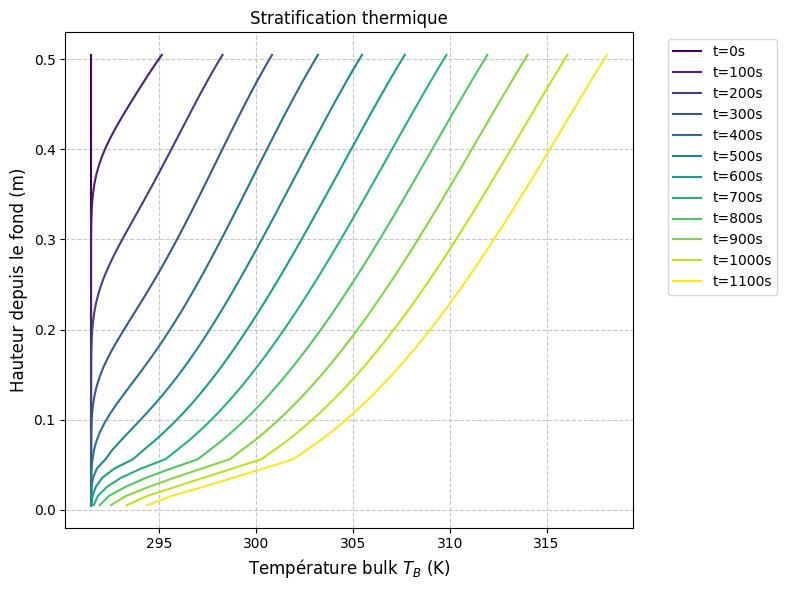

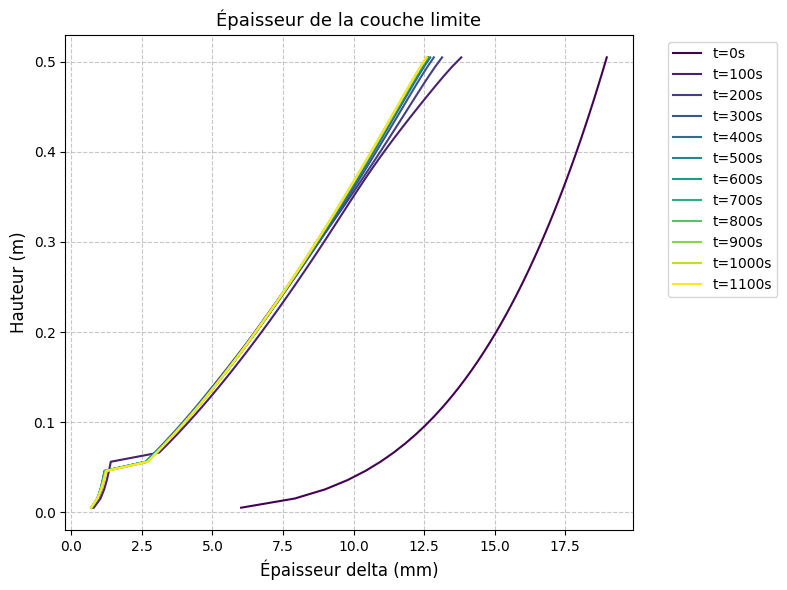

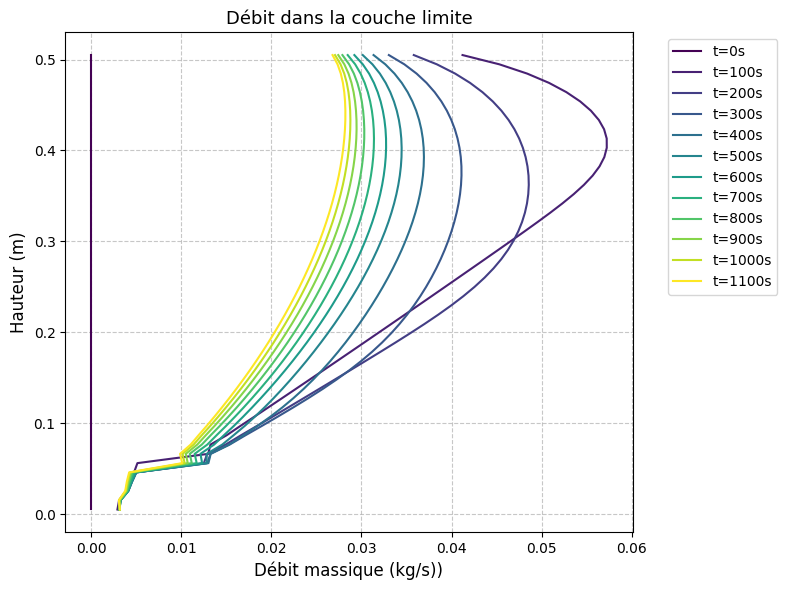

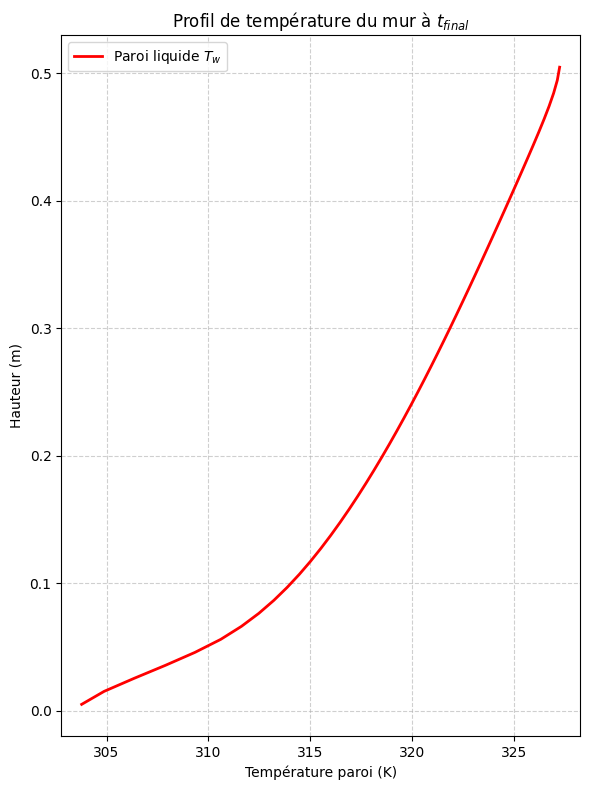

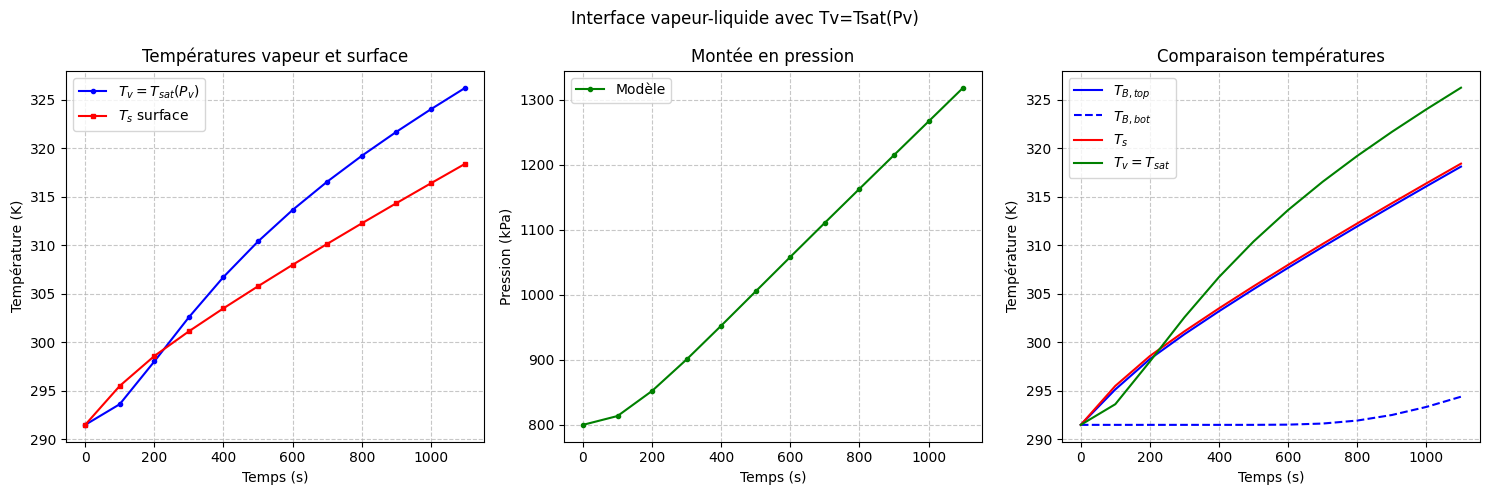

In [5]:
#### PLOT ####

y_coords = np.linspace(dx/2, H_liq_init-dx/2, Nx)
colors   = cm.viridis(np.linspace(0, 1, len(history_temp_bulk)))

# Stratification thermique
plt.figure(figsize=(8,6))
for idx, (t_profile, time) in enumerate(zip(history_temp_bulk, time_stamps)):
    plt.plot(t_profile, y_coords, color=colors[idx], label=f't={time}s')
plt.xlabel('Température bulk $T_B$ (K)', fontsize=12)
plt.ylabel('Hauteur depuis le fond (m)', fontsize=12)
plt.title('Stratification thermique', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Épaisseur couche limite
plt.figure(figsize=(8,6))
for idx, (d_profile, time) in enumerate(zip(history_delta, time_stamps)):
    plt.plot(d_profile*1000, y_coords, color=colors[idx], label=f't={time}s')
plt.xlabel('Épaisseur delta (mm)', fontsize=12)
plt.ylabel('Hauteur (m)', fontsize=12)
plt.title("Épaisseur de la couche limite", fontsize=13)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Débit massique
plt.figure(figsize=(8,6))
for idx, (d_profile, time) in enumerate(zip(history_m_dot, time_stamps)):
    plt.plot(d_profile, y_coords, color=colors[idx], label=f't={time}s')
plt.xlabel('Débit massique (kg/s))', fontsize=12)
plt.ylabel('Hauteur (m)', fontsize=12)
plt.title("Débit dans la couche limite", fontsize=13)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Température en paroi
plt.figure(figsize=(6,8))
plt.plot(Tw, y_coords, 'r-', lw=2, label='Paroi liquide $T_w$')
plt.xlabel('Température paroi (K)'); plt.ylabel('Hauteur (m)')
plt.title('Profil de température du mur à $t_{final}$')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend()
plt.xlim(min(Tw)-1, max(Tw)+1); plt.tight_layout(); plt.show()

# 4. Dynamique interface — comparaison avec valeurs article
fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].plot(time_stamps, history_Tv, 'b-o', ms=3, label='$T_v=T_{sat}(P_v)$')
axes[0].plot(time_stamps, history_Ts, 'r-s', ms=3, label='$T_s$ surface')
axes[0].set_xlabel('Temps (s)'); axes[0].set_ylabel('Température (K)')
axes[0].set_title('Températures vapeur et surface')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.7)

# Comparaison pression avec article (Fig 9b : 800 → ~1200 kPa à 1200s)
axes[1].plot(time_stamps, history_Pv, 'g-o', ms=3, label='Modèle')
axes[1].set_xlabel('Temps (s)'); axes[1].set_ylabel('Pression (kPa)')
axes[1].set_title('Montée en pression')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.7)

TB_top = [p[-1] for p in history_temp_bulk]
TB_bot = [p[0]  for p in history_temp_bulk]
axes[2].plot(time_stamps, TB_top, 'b-',  ms=3, label='$T_{B,top}$')
axes[2].plot(time_stamps, TB_bot, 'b--', ms=3, label='$T_{B,bot}$')
axes[2].plot(time_stamps, history_Ts, 'r-', ms=3, label='$T_s$')
axes[2].plot(time_stamps, history_Tv, 'g-', ms=3, label='$T_v=T_{sat}$')
axes[2].set_xlabel('Temps (s)'); axes[2].set_ylabel('Température (K)')
axes[2].set_title('Comparaison températures')
axes[2].legend(); axes[2].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Interface vapeur-liquide avec Tv=Tsat(Pv)", fontsize=12)
plt.tight_layout()
plt.show()
